# Correlations

Correlation adalah teknik untuk mengetahui bagaimana perubahan antara dua variabel yang dipasangkan, menyediakan insight apakah ada hubungan diantara mereka berdua. Teknik ini menunjukkan apakah dua variabel memiliki kecenderungan untuk bergerak bersama, dan jika iya, maka kearah mana. Akan ada dua kemungkinan:

1. Jika nilai korelasi itu positif, maka variable satu akan menaikkan variabel pasangannya.

2. Jika bernilai negatif, maka variabel satu akan menurunkan variabel pasangannya.

## Pearson Correlation

Pearson Correlation merupakan tolok ukur kekuatan dan arah hubungan antara dua variabel. Nilai koefisien ini berada di antara -1 dan 1 dengan nilai tertinggi menandakan adanya similaritas, sedangkan 0 mengartikan tidak adanya hubungan antara keduanya, dan nilai negatif menandakan keterikatan negatif. Ada beberapa syarat sebelum menggunakan Pearson Correlation

1. Variable bersifat kontinu

2. Hubungan antara variabel mendekati linear

3. Tidak memiliki nilai-nilai outlier yang ekstrim

Rumus yang digunakan untuk menghitung korelasi Pearson adalah

$$r = \frac{\sum (x_i - \bar{x}) (y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 (y_i - \bar{y})^2}}$$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. MEMBUAT DATA SIMULASI
# Kita buat dua variabel yang memiliki hubungan linear dan berdistribusi normal
np.random.seed(42)
work_exp = np.random.normal(loc=5, scale=2, size=100)  # rata-rata 5 tahun
salary = 3 + 2.5 * work_exp + np.random.normal(0, 1, 100)

df = pd.DataFrame({"Experience": work_exp, "Salary": salary})

print("--- 1. First Data (SIMULATION) ---")
print(df.head(), "\n")


# 2. Normality Asumption Test (SHAPIRO-WILK)
def normality_check(data, coloumn_name):
    stat, p_value = stats.shapiro(data)
    print(f"Shapiro-Wilk Test for {coloumn_name}:")
    print(f"Statistical Test = {stat:.4f}")
    print(f"p-value      = {p_value:.4f}")

    if p_value > 0.05:
        print(f"Conclusion  = Bell-Curved Data (p > 0.05)\n")
        return True
    else:
        print(f" Conclusion  = Non Bell-Curved Data (p <= 0.05)\n")
        return False

--- 1. First Data (SIMULATION) ---
   Experience     Salary
0    5.993428  16.568200
1    4.723471  14.388033
2    6.295377  18.395728
3    8.046060  22.312872
4    4.531693  14.167947 



Shapiro-Wilk Test for Experience:
Statistical Test = 0.9899
p-value      = 0.6552
Conclusion  = Bell-Curved Data (p > 0.05)

Shapiro-Wilk Test for Salary:
Statistical Test = 0.9935
p-value      = 0.9180
Conclusion  = Bell-Curved Data (p > 0.05)

 Pearson Correlation Coefficient (r) = 0.9778
 p-value (Significance)        = 0.0000


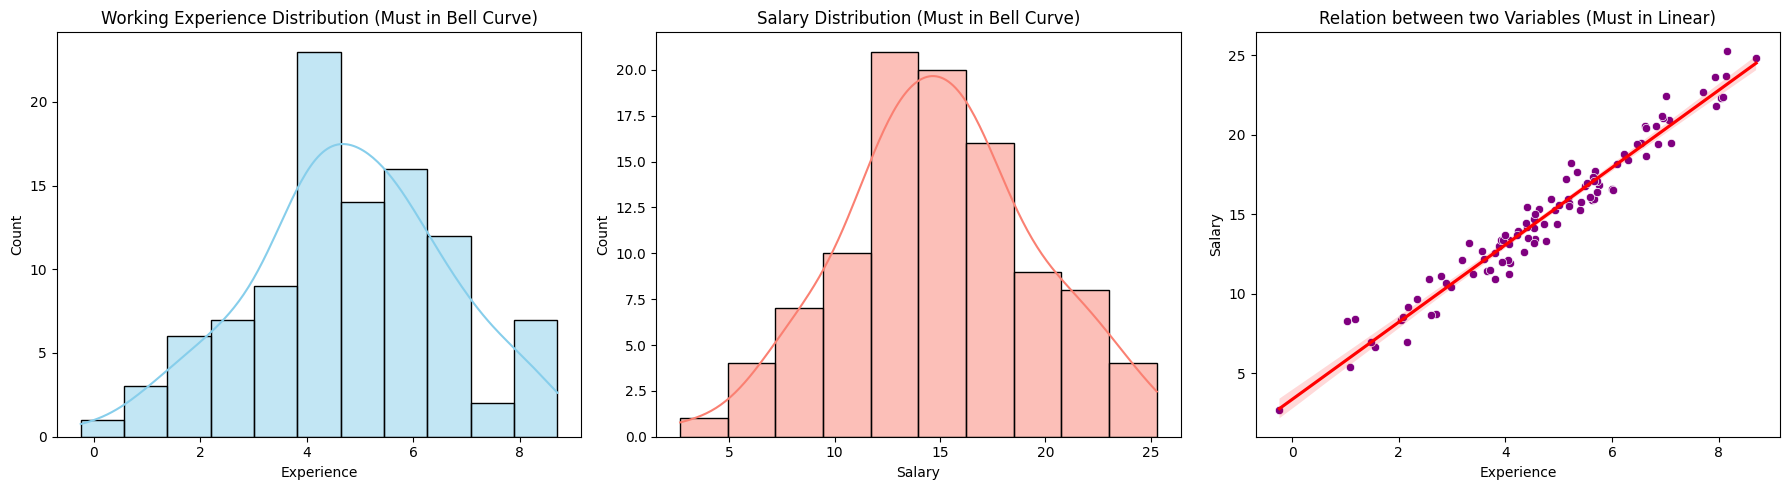

In [6]:
# uji asumsi untuk kedua variabel
normal_x = normality_check(df["Experience"], "Experience")
normal_y = normality_check(df["Salary"], "Salary")
r_coef, p_val_pearson = stats.pearsonr(df["Experience"], df["Salary"])

print(f" Pearson Correlation Coefficient (r) = {r_coef:.4f}")
print(f" p-value (Significance)        = {p_val_pearson:.4f}")


# 4. VISUALISASI UNTUK CEK GRAFIK (ASUMSI & HUBUNGAN LINEAR)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafik 1: Distribusi Variabel X
sns.histplot(df["Experience"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Working Experience Distribution (Must in Bell Curve)")

# Grafik 2: Distribusi Variabel Y
sns.histplot(df["Salary"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Salary Distribution (Must in Bell Curve)")

# Grafik 3: Scatter Plot (Asumsi Hubungan Linear)
sns.scatterplot(x="Experience", y="Salary", data=df, ax=axes[2], color="purple")
sns.regplot(x="Experience", y="Salary", data=df, ax=axes[2], scatter=False, color="red")
axes[2].set_title("Relation between two Variables (Must in Linear)")

plt.tight_layout()
plt.show()


## Spearman

Spearman correlation coefficient merupakan metode statistik non parametrik yang digunakan untuk mengukur kekuatan dan arah hubungan antara dua variabel berdasarkan peringkat datanya. Berbeda dengan Pearson yang menggunakan linearitas dari dua variabel yang ber numerik normal, Spearman menilai seberapa baik hubungan tersebut dapat digambarkan menggunakan fungsi monotonik.

Hubungan monotonik berarti ketika nilai satu variabel meningkat, nilai variabel lainnya cenderung ikut meningkat atau justru menurun secara konsisten, meskipun polanya tidak membentuk garis lurus sempurna. Spearman correlation can be used with either continuous or ordinal data, small sample of data, and it is relatively robust to outliers. Formulasi matematika untuk menghitung korelasi ini adalah

$$\rho = 1 - \frac{6\sum d^2_i}{n(n^2-1)}$$

 Spearman Correlation Coefficient (rho) = 1.0000
 Pearson Correlation Coefficient (r)       = 0.6284
 Dose  Side Effect  Rank X  Rank Y
    1            5     1.0     1.0
    2            6     2.0     2.0
    3            8     3.0     3.0
    4           11     4.0     4.0
    5           15     5.0     5.0
    6           22     6.0     6.0
    7           32     7.0     7.0
    8           47     8.0     8.0
    9           70     9.0     9.0
   10          105    10.0    10.0


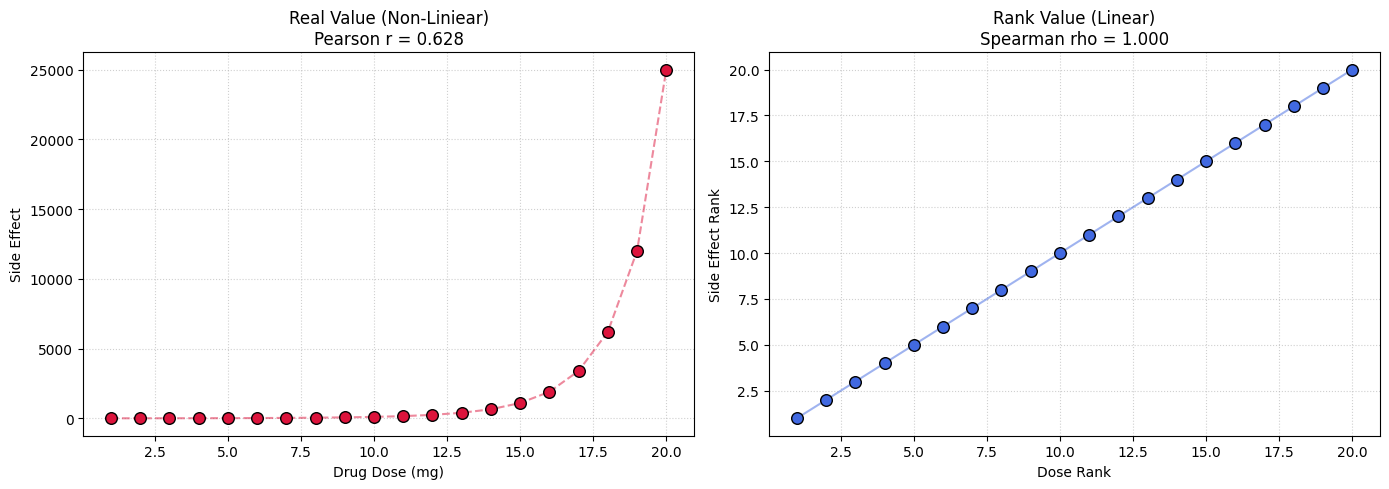

In [12]:
np.random.seed(42)
dose = np.arange(1, 21)

side_effect = np.array([5, 6, 8, 11, 15, 22, 32, 47, 70, 105, 160, 250, 400, 650, 1100, 1900, 3400, 6200, 12000, 25000])

rho_spearman, p_val_spearman = stats.spearmanr(dose, side_effect)
r_pearson, p_val_pearson = stats.pearsonr(dose, side_effect)

print(f" Spearman Correlation Coefficient (rho) = {rho_spearman:.4f}")
print(f" Pearson Correlation Coefficient (r)       = {r_pearson:.4f}")

df = pd.DataFrame({
    'Dose': dose,
    'Side Effect':side_effect,
    'Rank X': pd.Series(dose).rank(),
    'Rank Y': pd.Series(side_effect).rank()
})

print(df.head(10).to_string(index = False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(dose, side_effect, color='crimson', edgecolor='black', s=70, zorder=3)
ax1.plot(dose, side_effect, color='crimson', linestyle='--', alpha=0.5)
ax1.set_title(f"Real Value (Non-Liniear)\nPearson r = {r_pearson:.3f}", fontsize=12)
ax1.set_xlabel("Drug Dose (mg)")
ax1.set_ylabel("Side Effect")
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.scatter(df['Rank X'], df['Rank Y'], color='royalblue', edgecolor='black', s=70, zorder=3)
ax2.plot(df['Rank X'], df['Rank Y'], color='royalblue', linestyle='-', alpha=0.5)
ax2.set_title(f"Rank Value (Linear)\nSpearman rho = {rho_spearman:.3f}", fontsize=12)
ax2.set_xlabel("Dose Rank")
ax2.set_ylabel("Side Effect Rank")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()